# Домашняя работа №1: Предсказание успеха фильма

**Курс:** Машинное обучение и нейросети (ИТМО)  
**Задание:** Постановка задачи · Выбор метрики · Разведочный анализ данных (EDA)

**Студент: Шафоростов Данила 409879**

---
## Часть 1. Постановка задачи

### 1.1 Бизнес-постановка задачи

**Контекст.** Кинопроизводство — высокорискованная индустрия. По данным аналитических агентств, около 60–70% фильмов не окупают производственный бюджет в прокате. Продюсерские компании и стриминговые сервисы (Netflix, Disney+, Amazon) ежегодно вкладывают сотни миллионов долларов в проекты с неопределённым исходом.

**Бизнес-задача.** Требуется построить систему, которая на основе характеристик фильма, известных до или в начале проката (жанр, бюджет, язык оригинала, дата выхода и пр.), предсказывает, будет ли фильм **коммерчески успешным** — то есть соберёт ли кассовые сборы, превышающие двукратный производственный бюджет.

**Ценность для бизнеса:**
- Ранжировать питчи по вероятности успеха и распределять инвестиции рациональнее;
- Оптимизировать дату релиза и маркетинговый бюджет;
- Снизить финансовые риски студий и дистрибьюторов.

---

### 1.2 Постановка ML-задачи

Задача формулируется как **бинарная классификация** (supervised learning):

- **Целевая переменная:** `success` — бинарный признак
  - `1` — фильм успешен: `revenue / budget >= 2.0`
  - `0` — фильм не окупился: `revenue / budget < 2.0`

- **Входные признаки:** числовые (`budget`, `runtime`, `popularity`, `vote_average`) и категориальные (`genre`, `original_language`, `release_month`)

Согласно классификации из лекции «Типология задач машинного обучения», это задача **supervised classification** с дискретным выходом: модель возвращает метку класса (0 или 1) и вероятность успеха.

---

### 1.3 Набор данных

Используется **TMDB 5000 Movie Dataset** — публичный датасет на Kaggle от The Movie Database (TMDb).

**Ссылка:** https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

Датасет содержит метаданные ~4800 фильмов и включает:

| Признак | Тип | Описание |
|---|---|---|
| `budget` | float | Производственный бюджет (USD) |
| `revenue` | float | Кассовые сборы (USD) |
| `runtime` | float | Длительность фильма (минуты) |
| `vote_average` | float | Средняя оценка зрителей (1–10) |
| `vote_count` | int | Количество оценок |
| `popularity` | float | Индекс популярности TMDb |
| `genres` | str (JSON) | Список жанров |
| `original_language` | str | Язык оригинала |
| `release_date` | str | Дата выхода в прокат |
| `title` | str | Название фильма |
| `success` | int | **Целевая переменная** (вычисляется: 0/1) |

---
## Часть 2. Выбор и обоснование метрики

### Метрики: **F1-score (macro)** + **ROC-AUC**

**F1-score (macro)** — среднее гармоническое precision и recall, усреднённое по классам без взвешивания.

**Обоснование:** В задаче присутствует дисбаланс классов (фильмы с нулевым бюджетом или без сборов исключаются, но среди оставшихся классы неравномерны). Accuracy в такой ситуации вводит в заблуждение: модель, предсказывающая «успех» для всех фильмов, покажет высокую точность, но будет бесполезна. F1-score штрафует одновременно за пропущенные провалы (низкий recall класса 0) и за ложные тревоги (низкий precision), что напрямую соответствует бизнес-требованию — не пропускать убыточные проекты и не отвергать потенциально прибыльные.

**ROC-AUC** дополняет F1, оценивая качество ранжирования по всем порогам — важно для систем приоритизации питчей, где нужна не бинарная метка, а оценка относительного риска.



---
## Часть 3. Разведочный анализ данных (EDA)

### 3.0 Установка зависимостей и загрузка датасета

In [42]:
!pip install opendatasets -q

In [43]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import opendatasets as od

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)

In [44]:

print("Загрузка датасета TMDB 5000 Movie Dataset...")
od.download("https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata")

Загрузка датасета TMDB 5000 Movie Dataset...
Skipping, found downloaded files in "./tmdb-movie-metadata" (use force=True to force download)


In [45]:
# Чтение данных
df_raw = pd.read_csv('tmdb-movie-metadata/tmdb_5000_movies.csv')

print(f"\nРазмер датасета: {df_raw.shape[0]} строк x {df_raw.shape[1]} столбцов\n")
print("Первые 5 строк:")
df_raw.head()


Размер датасета: 4803 строк x 20 столбцов

Первые 5 строк:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.44,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.20,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.08,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.90,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.38,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.00,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.30,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.31,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.60,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.93,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.10,2124


### 3.1 Предобработка для EDA

In [46]:
df = df_raw.copy()

def extract_first_genre(genres_str):
    try:
        genres = json.loads(genres_str.replace("'", '"'))
        return genres[0]['name'] if genres else 'Unknown'
    except:
        return 'Unknown'

df['genre'] = df['genres'].apply(extract_first_genre)

df['release_date']  = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

df = df[(df['budget'] > 0) & (df['revenue'] > 0)].reset_index(drop=True)

df['roi']     = df['revenue'] / df['budget']
df['success'] = (df['roi'] >= 2.0).astype(int)
cols = ['title', 'budget', 'revenue', 'roi', 'runtime', 'vote_average',
        'vote_count', 'popularity', 'genre', 'original_language',
        'release_year', 'release_month', 'success']
df = df[cols]

print(f"Размер после фильтрации: {df.shape[0]} строк x {df.shape[1]} столбцов")
df.head()

Размер после фильтрации: 3229 строк x 13 столбцов


,title,budget,revenue,roi,runtime,vote_average,vote_count,popularity,genre,original_language,release_year,release_month,success
0,Avatar,237000000,2787965087,11.76,162.00,7.20,11800,150.44,Action,en,2009.00,12.00,1
1,Pirates of the Caribbean: At World's End,300000000,961000000,3.20,169.00,6.90,4500,139.08,Adventure,en,2007.00,5.00,1
2,Spectre,245000000,880674609,3.59,148.00,6.30,4466,107.38,Action,en,2015.00,10.00,1
3,The Dark Knight Rises,250000000,1084939099,4.34,165.00,7.60,9106,112.31,Action,en,2012.00,7.00,1
4,John Carter,260000000,284139100,1.09,132.00,6.10,2124,43.93,Action,en,2012.00,3.00,0


### 3.2 Базовые характеристики датасета

In [47]:
print(f"Строк:               {df.shape[0]}")
print(f"Признаков:           {df.shape[1]}")
print(f"Числовых признаков:  {df.select_dtypes(include=np.number).shape[1]}")
print(f"Объектных признаков: {df.select_dtypes(include='object').shape[1]}")
print()
print(df.dtypes)

Строк:               3229
Признаков:           13
Числовых признаков:  10
Объектных признаков: 3

title                 object
budget                 int64
revenue                int64
roi                  float64
runtime              float64
vote_average         float64
vote_count             int64
popularity           float64
genre                 object
original_language     object
release_year         float64
release_month        float64
success                int64
dtype: object


In [48]:
df.describe()

,budget,revenue,roi,runtime,vote_average,vote_count,popularity,release_year,release_month,success
count,3229.00,3229.00,3229.00,3229.00,3229.00,3229.00,3229.00,3229.00,3229.00,3229.00
mean,40654444.77,121242957.26,2954.82,110.72,6.31,977.29,29.03,2001.68,6.99,0.56
std,44396741.80,186302864.01,150610.10,20.97,0.87,1414.31,36.17,13.28,3.37,0.50
min,1.00,5.00,0.00,41.00,0.00,0.00,0.02,1916.00,1.00,0.00
25%,10500000.00,17000000.00,1.02,96.00,5.80,178.00,10.45,1998.00,4.00,0.00
50%,25000000.00,55184721.00,2.30,107.00,6.30,471.00,20.41,2005.00,7.00,1.00
75%,55000000.00,146292009.00,4.42,121.00,6.90,1148.00,37.34,2010.00,10.00,1.00
max,380000000.00,2787965087.00,8500000.00,338.00,8.50,13752.00,875.58,2016.00,12.00,1.00


**Наблюдение:** Переменные `budget`, `revenue`, `vote_count` и `popularity` имеют сильно скошенное (right-skewed) распределение — среднее существенно превышает медиану (например, средние сборы $121M при медиане $55M). Это характерно для финансовых данных и означает: при обучении моделей, чувствительных к масштабу (логистическая регрессия, KNN), понадобится логарифмическая трансформация или стандартизация. Обращает внимание экстремальный max ROI = 8 500 000 — очевидный выброс (малобюджетный хит), который необходимо проверить и при необходимости ограничить. Медианный ROI = 2.30 означает, что больше половины фильмов в выборке всё же окупаются — это следствие фильтрации нулевых бюджетов и сборов.

### 3.3 Анализ целевой переменной

In [49]:
success_counts = df['success'].value_counts().sort_index()
print("Распределение целевой переменной:")
print(success_counts.rename({0: 'Не окупился (0)', 1: 'Успешный (1)'}))
print(f"\nДоля успешных фильмов:  {success_counts[1]/len(df)*100:.1f}%")
print(f"Доля неуспешных:         {success_counts[0]/len(df)*100:.1f}%")

Распределение целевой переменной:
success
Не окупился (0)    1420
Успешный (1)       1809
Name: count, dtype: int64

Доля успешных фильмов:  56.0%
Доля неуспешных:         44.0%


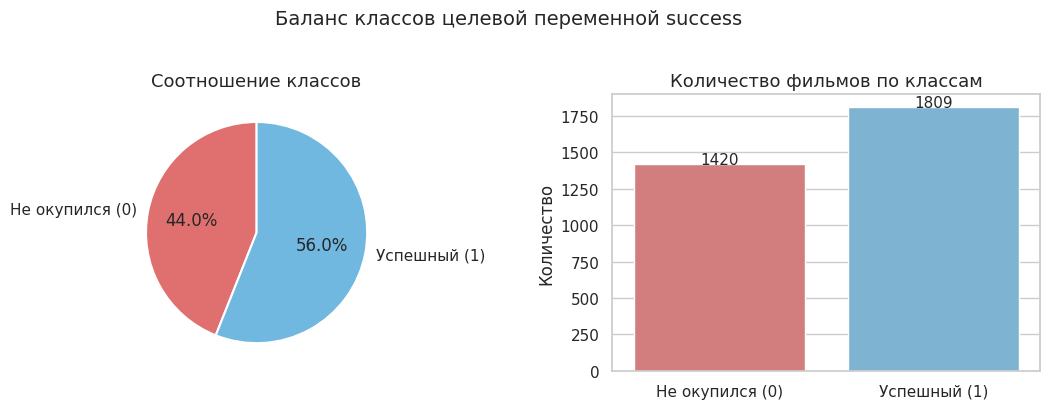

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Pie chart
axes[0].pie(
    success_counts.values,
    labels=['Не окупился (0)', 'Успешный (1)'],
    autopct='%1.1f%%',
    colors=['#e07070', '#70b8e0'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Соотношение классов', fontsize=13)

# Bar chart
sns.barplot(
    x=['Не окупился (0)', 'Успешный (1)'],
    y=success_counts.values,
    palette=['#e07070', '#70b8e0'],
    ax=axes[1]
)
for i, v in enumerate(success_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontsize=11)
axes[1].set_title('Количество фильмов по классам', fontsize=13)
axes[1].set_ylabel('Количество')

plt.suptitle('Баланс классов целевой переменной success', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Вывод:** Наблюдается умеренный дисбаланс классов. Это подтверждает выбор F1-macro и ROC-AUC как основных метрик.

### 3.4 Распределения числовых признаков

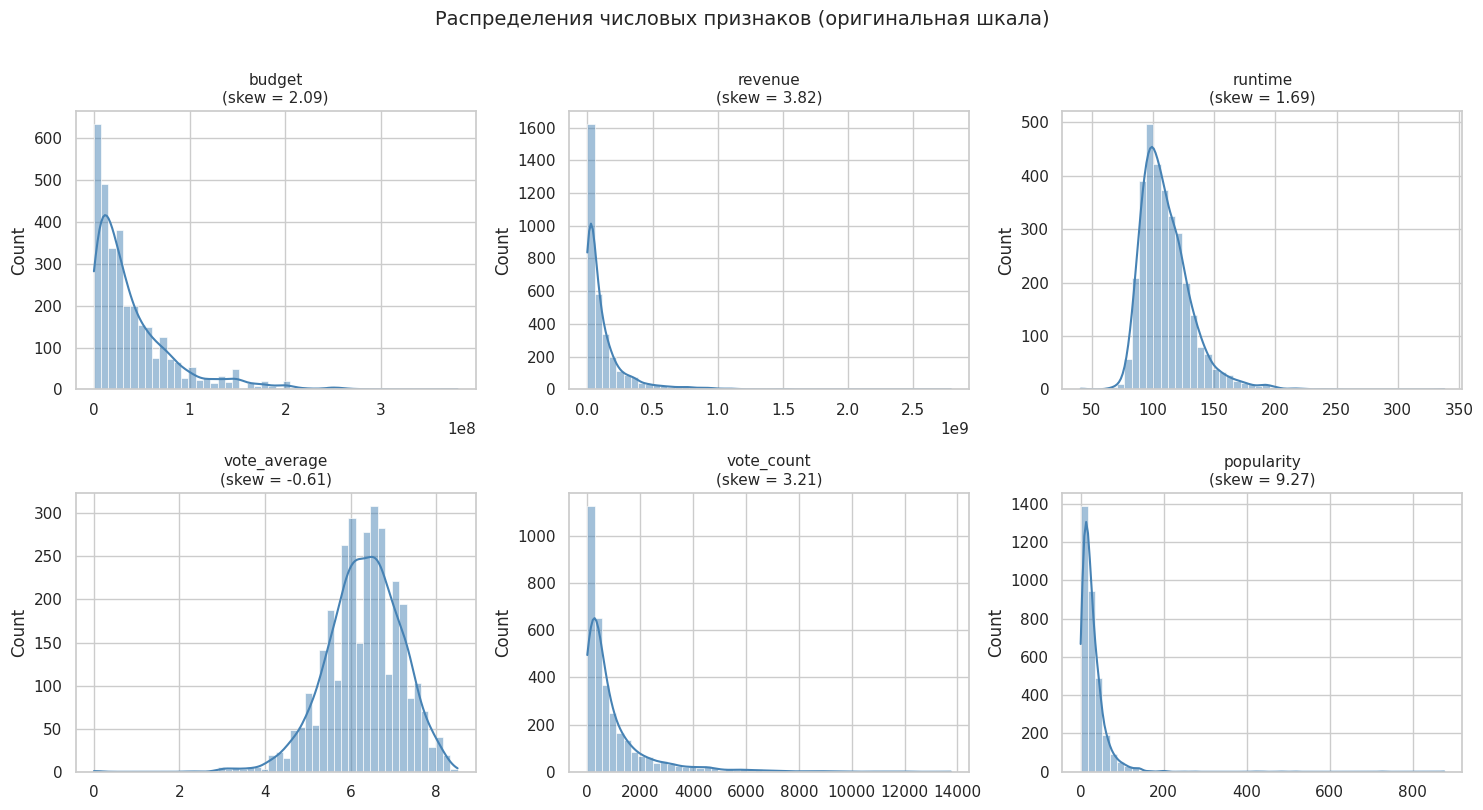

In [51]:
num_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_clean = df[col].dropna()
    sns.histplot(data_clean, bins=50, kde=True, ax=axes[i], color='steelblue')
    skewness = data_clean.skew()
    axes[i].set_title(f'{col}\n(skew = {skewness:.2f})', fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Распределения числовых признаков (оригинальная шкала)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Вывод:** `budget` (skew=2.09), `revenue` (skew=3.82), `vote_count` (skew=3.21) и `popularity` (skew=9.27 — экстремальная) имеют сильную правостороннюю асимметрию. `vote_average` — единственный признак с **левосторонней** асимметрией (skew=−0.61): большинство фильмов получают оценки выше среднего (6–7), а низкие оценки встречаются реже — это эффект «выживших», т.к. малоизвестные плохие фильмы просто не получают достаточно голосов. `runtime` имеет умеренную правостороннюю асимметрию (skew=1.69), большинство фильмов укладываются в 90–130 минут.

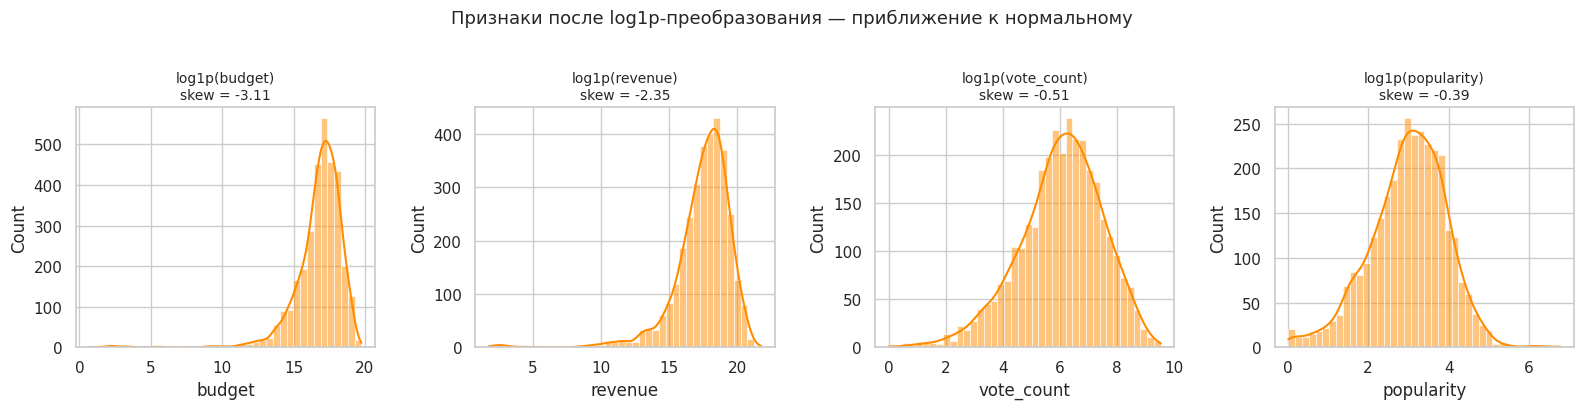

In [52]:
# Логарифмирование для сильно скошенных признаков
log_cols = ['budget', 'revenue', 'vote_count', 'popularity']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(log_cols):
    log_data = np.log1p(df[col].dropna())
    sns.histplot(log_data, bins=40, kde=True, ax=axes[i], color='darkorange')
    axes[i].set_title(f'log1p({col})\nskew = {log_data.skew():.2f}', fontsize=10)

plt.suptitle('Признаки после log1p-преобразования — приближение к нормальному', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Вывод:** После `log1p`-преобразования асимметрия резко снижается по абсолютному значению. Однако skew становится **отрицательным** (`budget`=−3.11, `revenue`=−2.35) — это говорит о том, что в данных преобладают фильмы с очень высокими бюджетами и сборами (так как мы отфильтровали нули, осталась верхняя часть распределения). Тем не менее для большинства алгоритмов такое преобразование всё равно предпочтительнее оригинальной шкалы. `vote_count` (skew=−0.51) и `popularity` (skew=−0.39) после log1p уже близки к нормальному — их можно использовать напрямую.

### 3.5 Числовые признаки в разрезе классов (Seaborn)

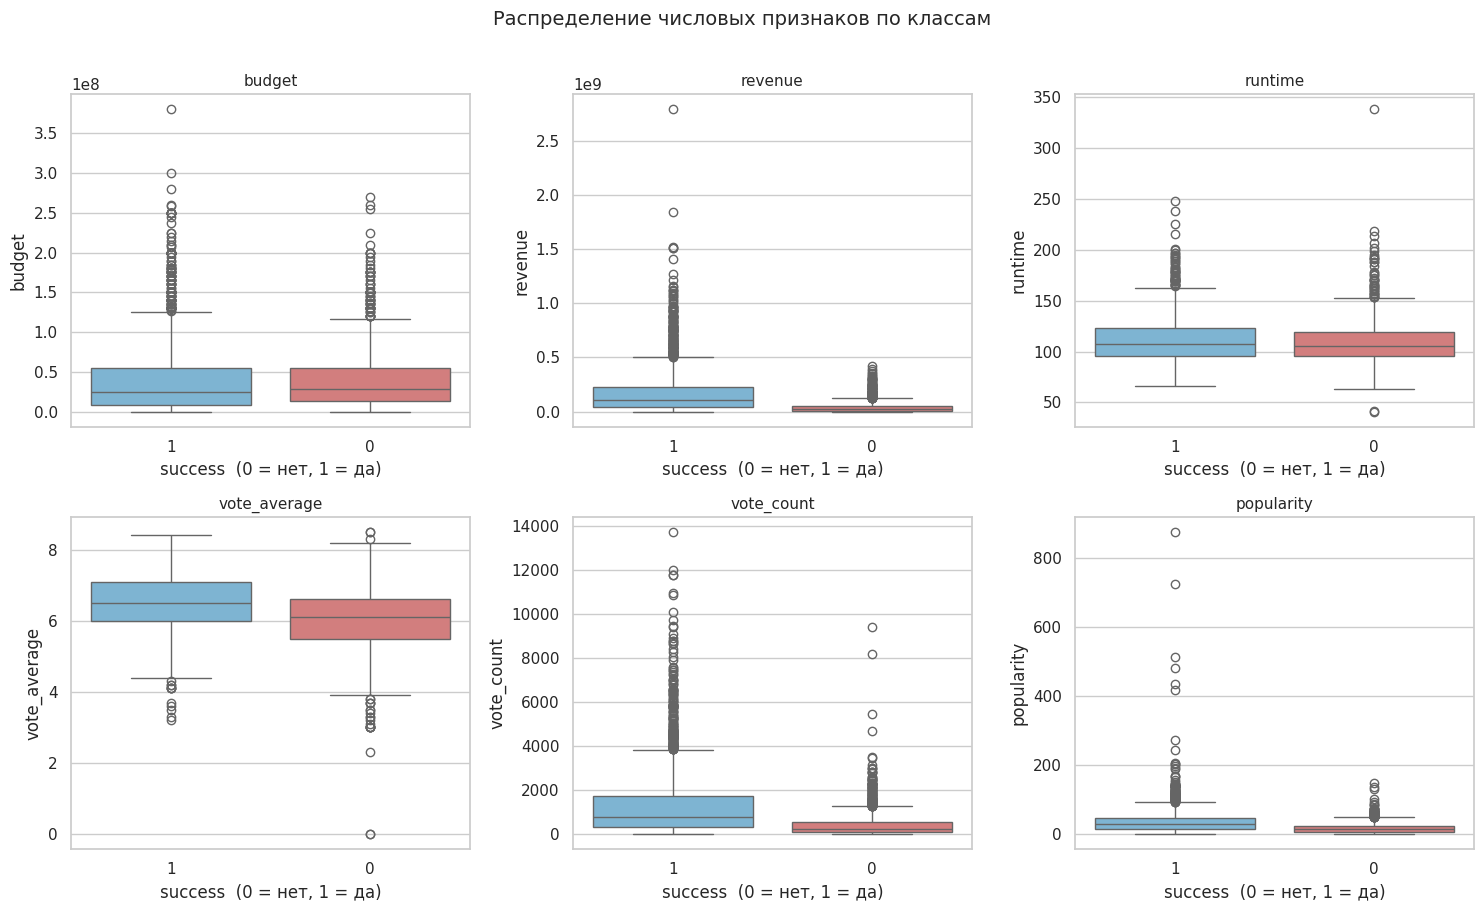

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
palette = {'0': '#e07070', '1': '#70b8e0'}

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df.dropna(subset=[col]).assign(success=lambda d: d['success'].astype(str)),
        x='success', y=col,
        palette=palette,
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('success  (0 = нет, 1 = да)')

plt.suptitle('Распределение числовых признаков по классам', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Вывод по боксплотам:**

- **`budget`:** медианные бюджеты успешных и неуспешных фильмов визуально близки (~25–30M), корреляция с `success` по матрице Пирсона составляет всего 0.03 — бюджет сам по себе слабо предсказывает успех. Много выбросов в обоих классах.
- **`revenue`:** наиболее наглядное различие — у успешных фильмов сборы значительно выше (медиана ~200M против ~30M у неуспешных). Однако `revenue` нельзя использовать как признак — это фактически целевая переменная (success = revenue/budget ≥ 2), использование его в модели создаёт data leakage.
- **`vote_average`:** у успешных фильмов медиана чуть выше (~6.8 vs ~6.2) — признак информативен, хотя разница невелика.
- **`vote_count` и `popularity`:** у успешных значительно выше, однако эти данные накапливаются после проката — включение в модель создаёт data leakage. Безопаснее использовать только данные, известные до выхода фильма.


### 3.6 Категориальные признаки (Plotly)

In [54]:
# Успех по жанрам
genre_stats = (
    df.groupby('genre')['success']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'success_rate', 'count': 'n_films'})
)
genre_stats = genre_stats[genre_stats['n_films'] >= 10].sort_values('success_rate', ascending=False)

fig = px.bar(
    genre_stats,
    x='genre', y='success_rate',
    color='success_rate',
    color_continuous_scale='RdYlGn',
    text=genre_stats['success_rate'].apply(lambda x: f'{x:.0%}'),
    hover_data={'n_films': True},
    title='Доля успешных фильмов по жанрам (TMDB 5000)',
    labels={'success_rate': 'Доля успешных', 'genre': 'Жанр', 'n_films': 'Кол-во фильмов'},
    height=460
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False, xaxis_tickangle=-30)
fig.add_hline(
    y=df['success'].mean(),
    line_dash='dash', line_color='grey',
    annotation_text='Среднее', annotation_position='top right'
)
fig.show()

**Вывод:** Жанры существенно различаются по доле успешных фильмов. Лидер — **Horror (78%)**, что объясняется низким бюджетом производства при широкой аудитории (высокий ROI даже при скромных сборах). Далее идут **Western (64%)**, **Animation (62%)**, **History и Adventure (61%)**. Аутсайдеры — **Music (45%)** и **War (22%)**: военные фильмы требуют больших бюджетов, но собирают нишевую аудиторию, что делает их коммерчески рискованными. Жанр является информативным признаком и должен быть включён в модель.

In [55]:
# Успех по языку оригинала (топ-8)
top_langs = df['original_language'].value_counts().head(8).index.tolist()
lang_df = df[df['original_language'].isin(top_langs)]

lang_stats = (
    lang_df.groupby('original_language')['success']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'success_rate', 'count': 'n_films'})
    .sort_values('success_rate', ascending=False)
)

lang_labels = {
    'en': 'Английский', 'fr': 'Французский', 'es': 'Испанский',
    'de': 'Немецкий', 'ja': 'Японский', 'ko': 'Корейский',
    'zh': 'Китайский', 'it': 'Итальянский', 'hi': 'Хинди',
    'pt': 'Португальский', 'ru': 'Русский'
}
lang_stats['lang_name'] = lang_stats['original_language'].map(lang_labels).fillna(lang_stats['original_language'])

fig = px.bar(
    lang_stats,
    x='lang_name', y='success_rate',
    color='n_films',
    color_continuous_scale='Blues',
    text=lang_stats['success_rate'].apply(lambda x: f'{x:.0%}'),
    hover_data={'n_films': True},
    title='Доля успешных фильмов по языку оригинала (топ-8 по количеству)',
    labels={'success_rate': 'Доля успешных', 'lang_name': 'Язык', 'n_films': 'Кол-во фильмов'},
    height=430
)
fig.update_traces(textposition='outside')
fig.show()

**Вывод:** Язык оригинала оказывает заметное влияние на коммерческий успех. Лидируют фильмы на **хинди (86%)** и **немецком (78%)** — однако их количество в датасете невелико, поэтому оценки нестабильны и могут быть случайными. Фильмы на **английском языке (56%)** — самая многочисленная группа (~3000 фильмов), и их доля успеха близка к среднему по датасету, что говорит о надёжности этой оценки. Аутсайдеры — **китайский (31%)** и **французский (24%)**: европейское и азиатское авторское кино традиционно ориентировано на фестивальную, а не кассовую аудиторию.

In [56]:
# Успех по месяцу выхода
month_names = {
    1:'Янв', 2:'Фев', 3:'Мар', 4:'Апр', 5:'Май', 6:'Июн',
    7:'Июл', 8:'Авг', 9:'Сен', 10:'Окт', 11:'Ноя', 12:'Дек'
}

month_stats = (
    df.groupby('release_month')['success']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'success_rate', 'count': 'n_films'})
)
month_stats['month_name'] = month_stats['release_month'].map(month_names)

fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(
    go.Bar(x=month_stats['month_name'], y=month_stats['n_films'],
           name='Кол-во фильмов', marker_color='lightsteelblue', opacity=0.7),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=month_stats['month_name'], y=month_stats['success_rate'],
               name='Доля успешных', mode='lines+markers',
               marker=dict(size=9, color='#c0392b'),
               line=dict(width=2.5)),
    secondary_y=True
)
fig.update_layout(
    title='Активность релизов и доля успешных фильмов по месяцам',
    xaxis_title='Месяц', height=440
)
fig.update_yaxes(title_text='Кол-во фильмов', secondary_y=False)
fig.update_yaxes(title_text='Доля успешных', secondary_y=True)
fig.show()

**Вывод:** Выражена **сезонность**. Наибольшая доля успешных фильмов приходится на **июнь (~65%)** и **июль** — традиционный летний «блокбастерный» сезон. Также высока доля в **декабре (~61%)** — праздничный сезон. Антирекорд — **сентябрь (~43%)**: это «мёртвый сезон» кинопроката, когда студии выпускают менее перспективные проекты. Количество релизов не совпадает с долей успешных — самый загруженный месяц (сентябрь, ~380 фильмов) оказывается наименее успешным. Признак `release_month`, а также производные бинарные признаки `is_summer` и `is_holiday_season` стоит включить в модель.

### 3.7 Интерактивный Scatter plot: бюджет vs сборы (Plotly)

In [57]:
plot_df = df.copy()
plot_df['log_budget']  = np.log1p(plot_df['budget'])
plot_df['log_revenue'] = np.log1p(plot_df['revenue'])
plot_df['success_label'] = plot_df['success'].map({0: 'Не окупился', 1: 'Успешный'})

fig = px.scatter(
    plot_df,
    x='log_budget',
    y='log_revenue',
    color='success_label',
    color_discrete_map={'Не окупился': '#e07070', 'Успешный': '#2980b9'},
    hover_data=['title', 'genre', 'release_year', 'vote_average'],
    opacity=0.55,
    title='Бюджет vs Кассовые сборы (логарифмическая шкала)',
    labels={
        'log_budget': 'log(Бюджет, USD)',
        'log_revenue': 'log(Сборы, USD)',
        'success_label': 'Класс'
    },
    height=520
)

x_min = plot_df['log_budget'].min()
x_max = plot_df['log_budget'].max()

fig.add_shape(type='line', x0=x_min, y0=x_min, x1=x_max, y1=x_max,
              line=dict(color='grey', dash='dot', width=1.5))
fig.add_annotation(text='revenue = budget', x=19, y=19.4, showarrow=False,
                   font=dict(color='grey', size=11))

fig.add_shape(type='line',
              x0=x_min, y0=x_min + np.log(2),
              x1=x_max, y1=x_max + np.log(2),
              line=dict(color='green', dash='dash', width=2))
fig.add_annotation(text='Граница успеха: revenue = 2 x budget', x=19, y=20.1,
                   showarrow=False, font=dict(color='green', size=11))

fig.show()

**Вывод:** Зелёная пунктирная линия — граница успеха. Точки выше неё — успешные фильмы, ниже — нет. Значительное перекрытие классов подтверждает: высокий бюджет необходим, но недостаточен.


### 3.8 Корреляционный анализ (Seaborn)

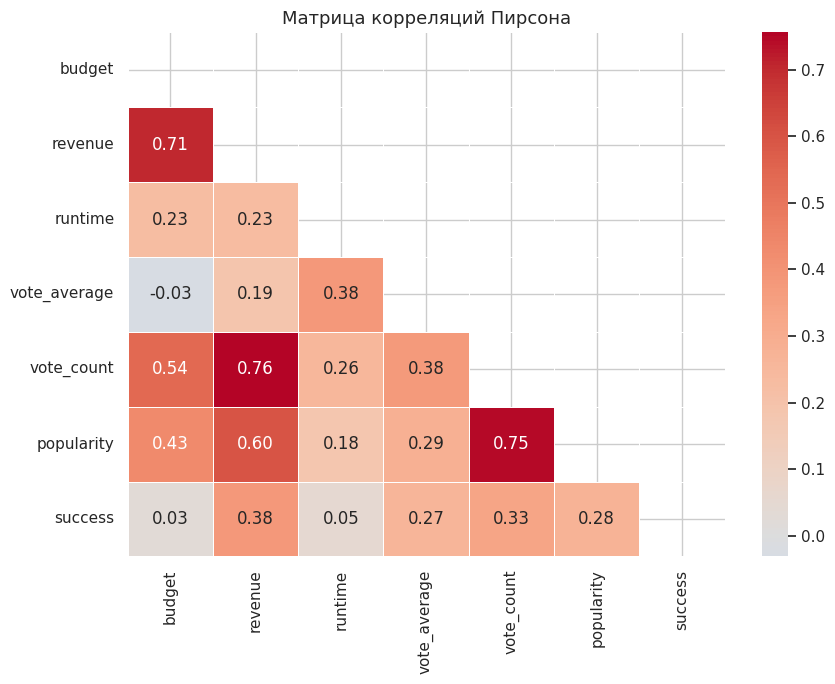

In [58]:
corr_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity', 'success']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Матрица корреляций Пирсона', fontsize=13)
plt.tight_layout()
plt.show()

**Вывод по корреляционной матрице:**

- `budget` ↔ `revenue`: r = 0.71 — высокая корреляция, что логично: более дорогие фильмы в среднем собирают больше.
- `vote_count` ↔ `popularity`: r = 0.75 — сильная мультиколлинеарность, оба признака измеряют схожее явление (охват и известность фильма).
- `vote_count` ↔ `revenue`: r = 0.76 — самая высокая корреляция в матрице.
- `budget` ↔ `success`: r = 0.03 — практически нулевая линейная зависимость. Бюджет сам по себе не определяет успех.
- `vote_average` ↔ `success`: r = 0.27 — слабая положительная связь, признак информативен.
- Все признаки имеют невысокую линейную корреляцию с `success` — это говорит о том, что зависимости в данных нелинейные, и линейные модели, скорее всего, покажут слабые результаты. Алгоритмы на основе деревьев (случайный лес, градиентный бустинг) должны справиться лучше.

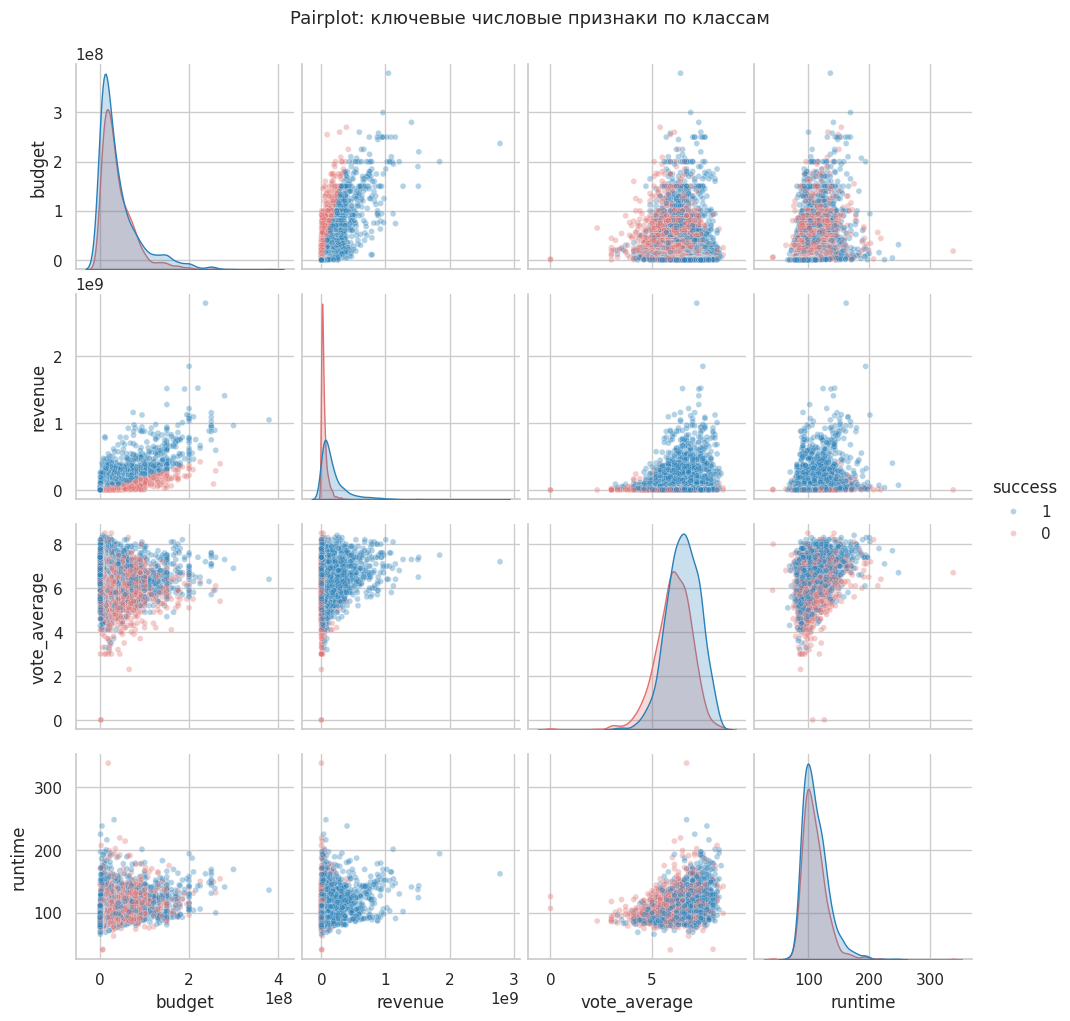

In [59]:
# Pairplot
pair_cols = ['budget', 'revenue', 'vote_average', 'runtime', 'success']
pair_df = df[pair_cols].dropna().copy()
pair_df['success'] = pair_df['success'].astype(str)

g = sns.pairplot(
    pair_df,
    hue='success',
    palette={'0': '#e07070', '1': '#2980b9'},
    plot_kws={'alpha': 0.35, 's': 18},
    diag_kind='kde'
)
g.figure.suptitle('Pairplot: ключевые числовые признаки по классам', y=1.02, fontsize=13)
plt.show()

**Вывод:** На scatter-матрице видно, что лучшее визуальное разделение классов достигается по оси `revenue` — синие точки (успешные) концентрируются значительно выше по сборам. `budget` почти **не разделяет** классы: облака красных и синих точек перекрываются по всему диапазону бюджетов. Диагональные KDE-графики: `vote_average` у класса 1 смещён чуть вправо (выше оценки), `runtime` практически идентичен в обоих классах. Вывод: ни один признак в одиночку не обеспечивает хорошего разделения — необходима **комбинация признаков** и нелинейная модель.

### 3.9 Выбросы (Seaborn boxplot)

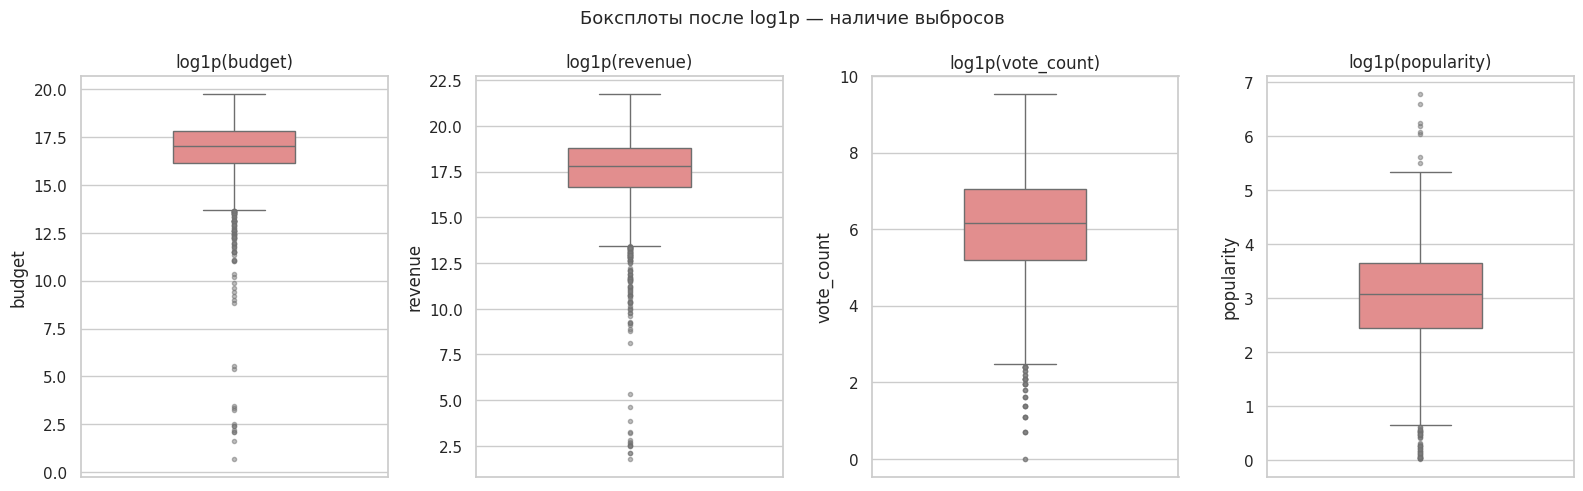

In [60]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
outlier_cols = ['budget', 'revenue', 'vote_count', 'popularity']

for i, col in enumerate(outlier_cols):
    log_col = np.log1p(df[col].dropna())
    sns.boxplot(
        y=log_col, ax=axes[i],
        color='lightcoral', width=0.4,
        flierprops=dict(marker='o', markerfacecolor='grey', markersize=3, alpha=0.5)
    )
    axes[i].set_title(f'log1p({col})')

plt.suptitle('Боксплоты после log1p — наличие выбросов', fontsize=13)
plt.tight_layout()
plt.show()

**Вывод:** После логарифмирования выбросы остаются, но их характер меняется. Для `budget` и `revenue` выбросы теперь **нижние** (малобюджетные фильмы с минимальными сборами) — именно они искажают распределение в отрицательную сторону после log1p. `popularity` имеет верхние выбросы — несколько фильмов с аномально высоким индексом популярности.

### 3.10 Динамика успеха по годам (Plotly)

In [61]:
year_stats = (
    df.groupby('release_year')
    .agg(n_films=('success', 'count'), success_rate=('success', 'mean'))
    .reset_index()
)
year_stats = year_stats[year_stats['n_films'] >= 10]

fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(
    go.Bar(x=year_stats['release_year'], y=year_stats['n_films'],
           name='Кол-во фильмов', marker_color='lightsteelblue', opacity=0.6),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=year_stats['release_year'], y=year_stats['success_rate'],
               name='Доля успешных', mode='lines+markers',
               marker=dict(size=7, color='#c0392b'),
               line=dict(width=2.5)),
    secondary_y=True
)
fig.update_layout(
    title='Динамика кинопроизводства и доли успешных фильмов по годам',
    xaxis_title='Год', height=450
)
fig.update_yaxes(title_text='Кол-во фильмов', secondary_y=False)
fig.update_yaxes(title_text='Доля успешных', secondary_y=True)
fig.show()

**Вывод:** Динамика по годам нетривиальна. В 1975–1989 годах доля успешных фильмов была высокой (0.7–0.8), но выборка мала (до 30 фильмов в год) — оценки нестабильны. С 1990 по 1995 год наблюдается **резкое падение** доли успешных (~0.42) при одновременном росте числа фильмов — индустрия укрупнялась и конкуренция возросла. С 2000-х доля стабилизировалась на уровне 0.5–0.6 при высоком объёме выборки (100–160 фильмов в год). Согласно лекции «Архитектура ML-решения», при деплойменте необходимо учитывать **дрейф данных**: паттерны 1980-х не актуальны сегодня. Рекомендуется обучать модель только на данных последних 20–25 лет и регулярно переобучать на новых релизах.

## Итоговые выводы по EDA

После фильтрации строк с нулевыми бюджетами и сборами датасет содержит **3229 фильмов** с умеренным дисбалансом классов: 56% успешных против 44% неуспешных. Это подтверждает выбор F1-macro и ROC-AUC как основных метрик.

Числовые признаки (`budget`, `revenue`, `vote_count`, `popularity`) имеют сильную правостороннюю асимметрию и требуют логарифмического преобразования перед подачей в модель. `vote_average` — единственный признак с лёгкой левосторонней асимметрией (skew = −0.61), близкий к нормальному.

Наиболее информативными для предсказания успеха являются: **жанр** (Horror — 78%, War — 22%), **месяц релиза** (июнь — лидер с 65%, сентябрь — антирекорд с 43%) и **`vote_average`**. Бюджет как таковой слабо предсказывает успех (r = 0.03 с target) — контринтуитивный, но важный вывод.

Признаки `revenue`, `vote_count` и `popularity` содержат информацию о целевой переменной или формируются после выхода фильма, поэтому их использование в модели требует осторожности.

**В финальный набор признаков рекомендуется включить:** `budget` (после log1p), `runtime`, `vote_average`, `genre`, `original_language`, `release_month`, `release_year`.
